In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('IPFQR_QualityMeasures_Facility.csv')

In [ ]:
df['READM-30-IPF Rate'] = pd.to_numeric(df['READM-30-IPF Rate'], errors = 'coerce')

In [ ]:
data = df['READM-30-IPF Rate'].dropna()

In [ ]:
counts, big_edges = np.histogram(data, bins = 20)

In [ ]:
bin_centers = 0.5 * (big_edges[:-1] + big_edges[1:])

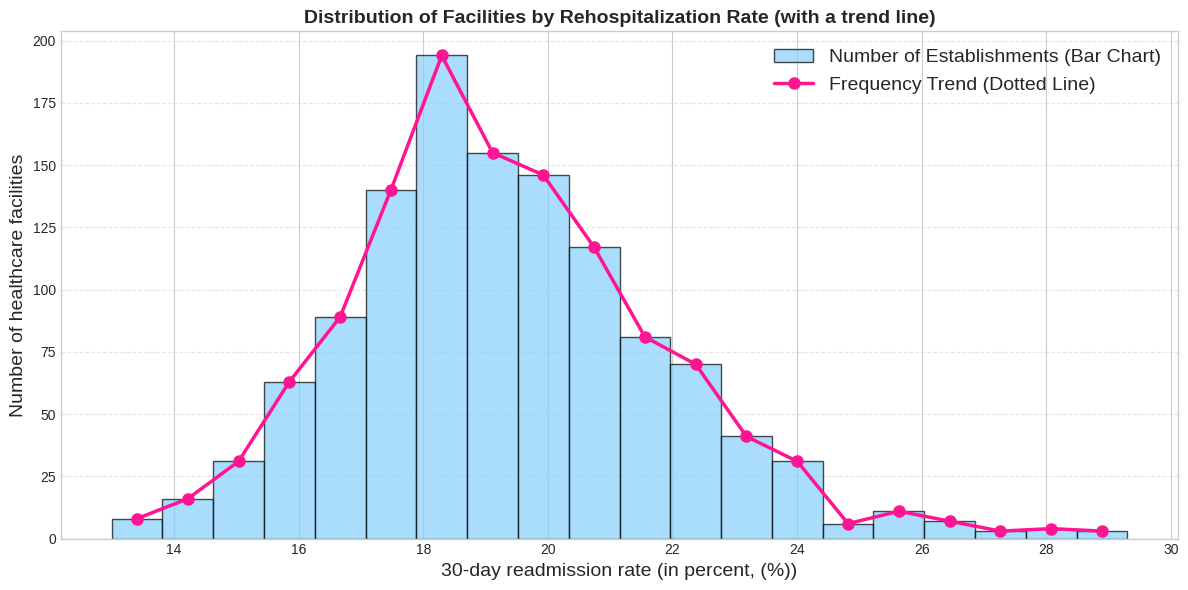

In [ ]:
plt.figure(figsize = (12, 6))
plt.hist(
    data,
    bins = 20,
    color = '#87CEFA',
    edgecolor = 'black',
    alpha = 0.7,
    label = 'Number of Establishments (Bar Chart)'
)
plt.plot(
    bin_centers,
    counts,
    marker = 'o',
    color = '#FF1493',
    linestyle = '-',
    linewidth = 2.5,
    markersize = 8,
    label = 'Frequency Trend (Dotted Line)'
)
plt.title(
    'Distribution of Facilities by Rehospitalization Rate (with a trend line)',
    fontsize = 14,
    fontweight = 'bold'
)
plt.xlabel(
    '30-day readmission rate (in percent, (%))',
    fontsize = 14
)
plt.ylabel(
    'Number of healthcare facilities',
    fontsize = 14
)
plt.legend(
    fontsize = 14,
    loc = "upper right"
)
plt.grid(
    axis = 'y',
    linestyle = '--',
    alpha = 0.5
)
plt.tight_layout()
plt.savefig('HistogramLineCombination_IPFQR_QualityMeasures_Facility')
plt.show()

In [ ]:
set_of_states = df['State'].value_counts().head(12).index
subset_df = df[df['State'].isin(set_of_states)]
crosstab = pd.crosstab(subset_df['State'], subset_df['READM-30-IPF Category'])
crosstab['Total Number Of Facilities'] = crosstab.sum(axis = 1)
crosstab.sort_values(
    'Total Number Of Facilities',
    ascending = True
).drop('Total Number Of Facilities', axis = 1)
colors = ['#88cfae', '#f4a6c1', '#8cb8e5', '#fcd595', '#c3aed6', '#de7a76']
plt.style.use('seaborn-v0_8-whitegrid')

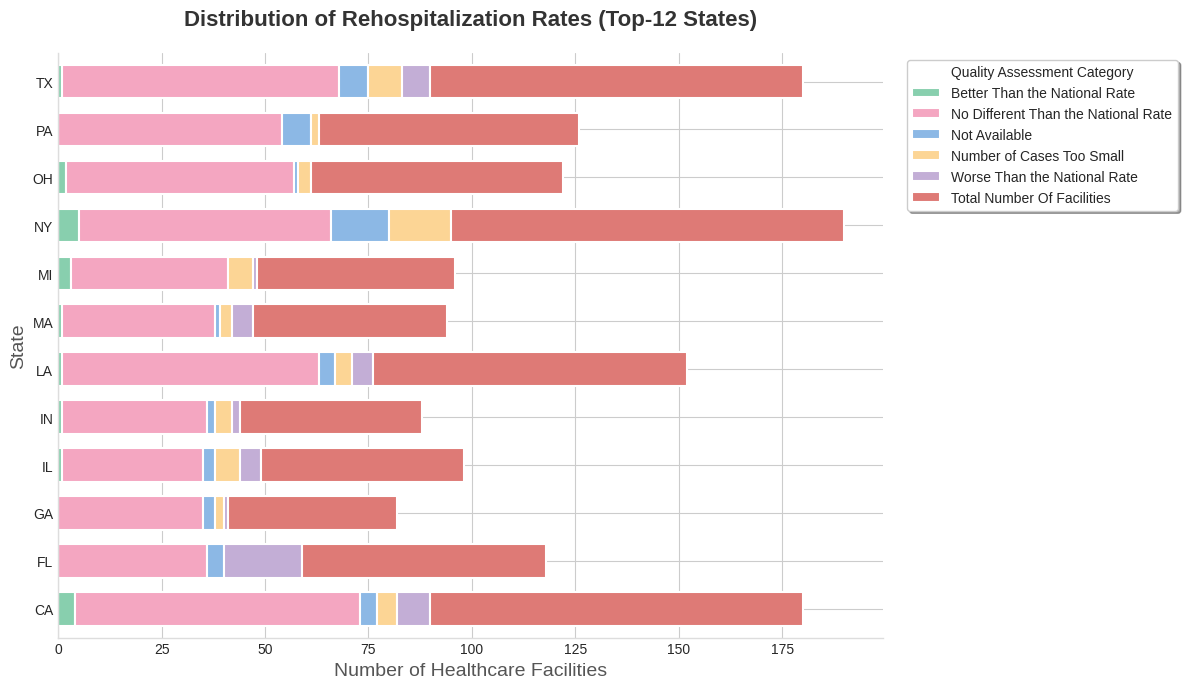

In [ ]:
fig, ax = plt.subplots(figsize = (12, 7))
crosstab.plot(
    kind = 'barh',
    stacked = True,
    color = colors[:len(crosstab.columns)],
    ax = ax,
    width = 0.7,
    edgecolor = 'white',
    linewidth = 1.5
)
ax.set_title(
    'Distribution of Rehospitalization Rates (Top-12 States)',
    fontsize = 16,
    fontweight = 'bold',
    pad = 20,
    color = '#333333',
)
ax.set_xlabel(
    'Number of Healthcare Facilities',
    fontsize = 14,
    color = '#555555'
)
ax.set_ylabel(
    'State',
    fontsize = 14,
    color = '#555555'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')
ax.legend(
    title = 'Quality Assessment Category',
    bbox_to_anchor = (1.02, 1),
    loc = 'upper left',
    frameon = True,
    fancybox = True,
    shadow = True
)
plt.tight_layout()
plt.savefig(
    'AestheticStackedBar_IPFQR_QualityMeasures_Facility.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

In [ ]:
df = pd.read_csv("IPFQR_QualityMeasures_Facility.csv")
df['READM-30-IPF Rate'] = pd.to_numeric(df['READM-30-IPF Rate'], errors = 'coerce')

In [ ]:
filtered_valid_rates_df = df.dropna(
    subset = ['READM-30-IPF Rate', 'State']
).copy()

In [ ]:
filtered_valid_rates_df['Rounded_Rate'] = filtered_valid_rates_df['READM-30-IPF Rate'].round().astype(int)

In [ ]:
set_of_states = df['State'].value_counts().head(5).index
set_of_states_df = filtered_valid_rates_df[filtered_valid_rates_df['State'].isin(set_of_states)]

In [ ]:
grouped_by_df = set_of_states_df.groupby(['Rounded_Rate', 'State']).size().unstack(fill_value = 0)

In [ ]:
grouped_by_df = grouped_by_df.loc[16:23]

In [ ]:
colors = ['#f8b8d0', '#fce4ec', '#5c3a93', '#a991c8', '#f392b8']

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

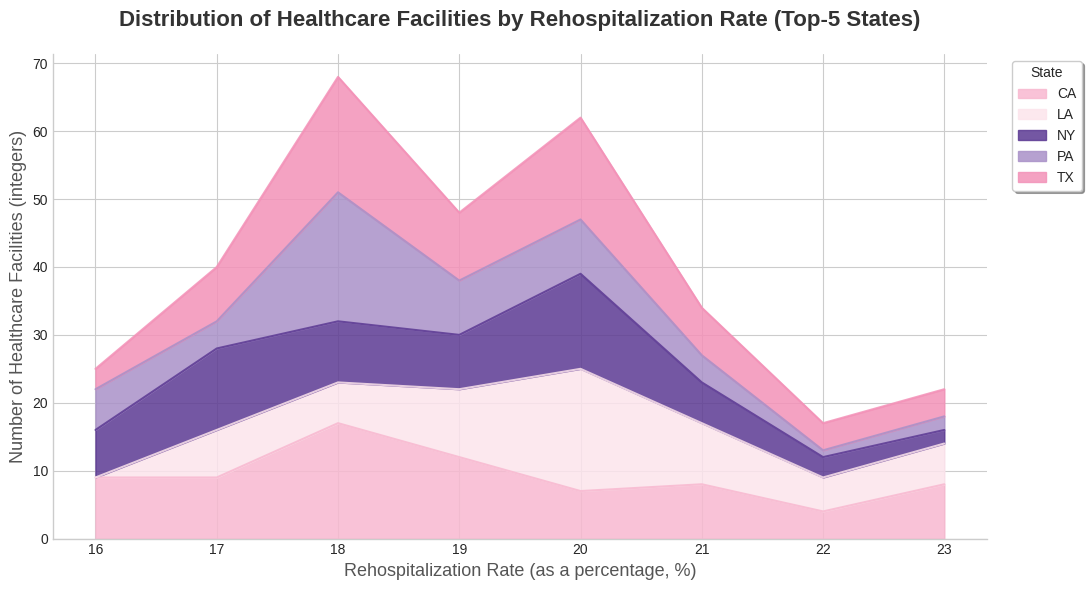

In [ ]:
fig, ax = plt.subplots(figsize = (11, 6))
grouped_by_df.plot(
    kind = 'area',
    stacked = True,
    color = colors[:len(set_of_states)],
    ax = ax,
    alpha = 0.85
)
ax.set_title(
    'Distribution of Healthcare Facilities by Rehospitalization Rate (Top-5 States)',
    fontsize = 16,
    fontweight = 'bold',
    pad = 20,
    color = '#333333'
)
ax.set_xlabel(
    'Rehospitalization Rate (as a percentage, %)',
    fontsize = 13,
    color = '#555555'
)
ax.set_ylabel(
    'Number of Healthcare Facilities (integers)',
    fontsize = 13,
    color = '#555555'
)
ax.legend(
    title = 'State',
    bbox_to_anchor = (1.02, 1),
    loc = 'upper left',
    frameon = True,
    shadow = True
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(
    'StackedAreaChart_IPFQR_QualityMeasures_Facility.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

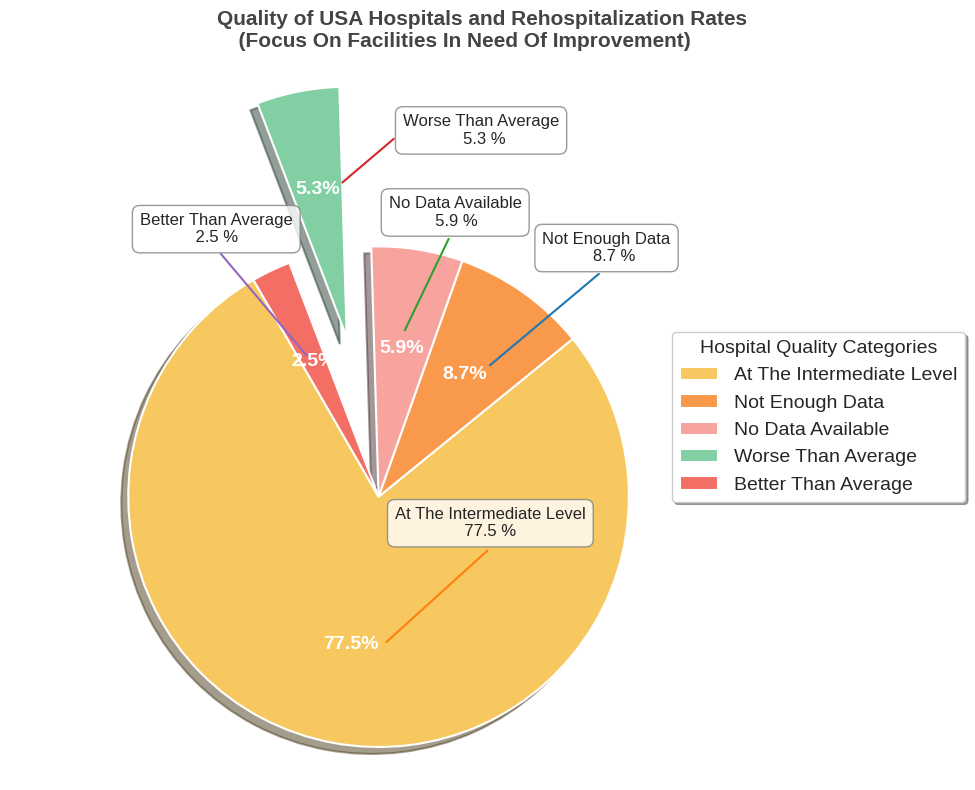

In [ ]:
df = pd.read_csv("IPFQR_QualityMeasures_Facility.csv")
category_counts = df['READM-30-IPF Category'].value_counts()
labels_map = {
  'No Different Than the National Rate': 'At The Intermediate Level',
  'Number of Cases Too Small': 'Not Enough Data',
  'Not Available': 'No Data Available',
  'Worse Than the National Rate': 'Worse Than Average',
  'Better Than the National Rate': 'Better Than Average'
}
labels = [labels_map.get(label, label) for label in category_counts.index]
sizes = category_counts.values
explode = [0.65 if label == 'Worse Than Average' else 0 for label in labels]
colors = ['#f6c85f', '#f9994c', '#f7a49f', '#81cfa2', '#f36e65']
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize = (9, 8))
wedges, texts, autotexts = ax.pie(
  sizes,
  explode = explode,
  labels = None,
  autopct = '%1.1f%%',
  shadow = True,
  startangle = 120,
  colors = colors,
  wedgeprops = {
    'edgecolor': 'white',
    'linewidth': 1.5
  },
  textprops = {
    'fontsize': 14,
    'fontweight': 'bold',
    'color': 'white'
  }
)
ax.legend(
    wedges,
    labels,
    title = "Hospital Quality Categories",
    loc = "center left",
    bbox_to_anchor = (1, 0, 0.5, 1),
    fontsize = 14,
    title_fontsize = 14,
    frameon = True,
    shadow = True
)
ax.axis('equal')
plt.title(
    '                                    Quality of USA Hospitals and Rehospitalization Rates\n                              (Focus On Facilities In Need Of Improvement)',
    fontsize = 15,
    fontweight = 'bold',
    pad = 5,
    color = '#444444'
)
x1 = [0.445, 0.880]
y1 = [0.525, 0.890]
x2 = [0.435, 0.031]
y2 = [-0.215, -0.581]
x3 = [0.105, 0.280]
y3 = [0.665, 1.030]
x4 = [-0.145, 0.061]
y4 = [1.255, 1.430]
x5 = [-0.288, -0.630]
y5 = [0.565, 0.970]
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.plot(x3, y3)
plt.plot(x4, y4)
plt.plot(x5, y5)
plt.text(
  0.789,
  0.755,
  "Not Enough Data\n           8.7 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.text(
  0.529,
  0.376,
  "At The Intermediate Level\n               77.5 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.text(
  0.518,
  0.804,
  "No Data Available\n          5.9 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.text(
  0.543,
  0.917,
  "Worse Than Average\n             5.3 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.text(
  0.079,
  0.781,
  "Better Than Average\n            2.5 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.tight_layout()
plt.savefig(
    'pie_with_legend.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()